In [12]:
import sys
import os

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')


import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

In [13]:
X1 = pd.read_csv("mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("mod_data/y3.1", index_col="QSPRID")


In [14]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))

,0,1,2,3,4,5,6,7,8,9,...,2390,2391,2392,2393,2394,2395,2396,2397,2398,2399
0,-0.296463,-1.014346,0.704087,0.197034,-0.199916,0.056990,-1.262282,-0.085669,-1.053805,0.296247,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,0.856668
1,-0.670941,-0.525577,-1.236676,1.502286,0.377970,-0.372174,-0.045401,-0.789457,0.021136,-0.509625,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.299228
2,0.629879,0.514115,-0.293469,1.144865,-1.295461,-1.086432,1.400654,1.220583,1.660234,-0.789349,...,-0.290593,6.044705,1.105679,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.866536
3,0.373012,-1.030634,0.820882,0.936072,-0.378374,1.713116,1.237002,-0.435967,-0.914606,1.251034,...,-0.290593,-0.165434,1.105679,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.567226
4,-1.172401,0.684663,-0.397464,-1.756755,1.804830,0.697231,-0.604966,-1.927427,-0.766635,-1.374831,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,1.510832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,-1.193043,-0.487364,-0.908142,1.116066,-0.271553,-0.376130,-0.633163,0.123939,1.031423,0.226711,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.918624
790,1.125096,1.186714,-0.128442,-0.240725,-1.569522,-0.687927,1.238028,0.160632,-1.380454,0.755241,...,-0.290593,-0.165434,0.291367,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,0.891481
791,-0.823325,-0.610447,-0.668821,1.034534,-0.353845,-0.572354,-0.119446,0.004899,1.136635,0.244145,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.984171
792,-0.336960,-1.640396,-0.558868,0.358328,-0.148476,0.579681,-1.060386,0.396513,-0.133678,0.005032,...,-0.290593,-0.165434,0.437196,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.059823


In [16]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit_transform(X1)
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [17]:
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

In [18]:
n_components

323

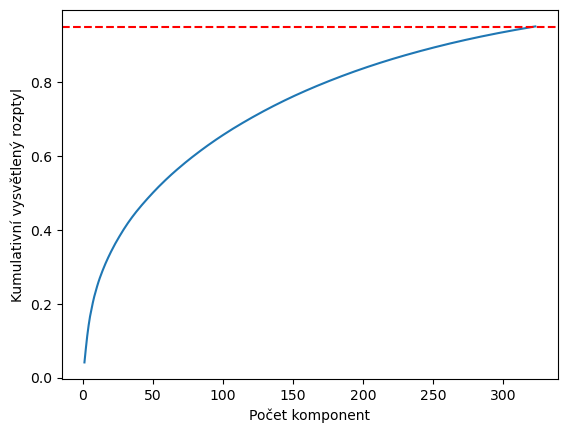

In [19]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [11]:
import xgboost
print(xgboost.__file__)


/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/__init__.py


In [2]:
from xgboost import XGBClassifier
from sklearn.datasets import make_classification

params = {
    "tree_method": "gpu_hist",  # Use GPU
    "predictor": "gpu_predictor",
    "objective": "binary:logistic"
}
model = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, device="cuda", **params)


model.fit(X1, y1)


NameError: name 'X1' is not defined

In [20]:
import random
import numpy as np
import xgboost as xgb
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score
from sklearn.model_selection import train_test_split

param_space_xgb = {
    'n_estimators': (100, 2000),  # int range (number of boosting rounds)
    'learning_rate': np.logspace(np.log10(1e-5), np.log10(1e-1), num=50).tolist(), # float range
    'max_depth': (3, 15), # int range (maximum depth of a tree)
    'subsample': (0.6, 1.0), # float range (subsample ratio of the training instance)
    'colsample_bytree': (0.6, 1.0), # float range (subsample ratio of columns when constructing each tree)
    'gamma': np.logspace(np.log10(1e-5), np.log10(1), num=50).tolist(), # float range (minimum loss reduction required to make a further partition)
    'reg_alpha': np.logspace(np.log10(1e-5), np.log10(1e-1), num=50).tolist(), # float range (L1 regularization term on weights)
    'reg_lambda': np.logspace(np.log10(1e-5), np.log10(1e-1), num=50).tolist(), # float range (L2 regularization term on weights)
    'min_child_weight': (1, 20), # int range (minimum sum of instance weight (hessian) needed in a child)
    'random_state': [69], # Fixed seed for reproducibility
    'objective': ['binary:logistic'], # For binary classification (outputs probabilities)
    'eval_metric': ['logloss'], # Metric for evaluation during training with early stopping
    'use_label_encoder': [False], # Suppress a common warning in newer XGBoost versions
    'tree_method': ['hist'], # Faster for larger datasets, especially on GPUs
}

def generate_random_params_xgb(param_space_dict):
    params = {}
    for param_name, values in param_space_dict.items():
        if isinstance(values, tuple) and len(values) == 2:
            min_val, max_val = values
            if isinstance(min_val, int) and isinstance(max_val, int):
                params[param_name] = random.randint(min_val, max_val)
            else: # float
                params[param_name] = random.uniform(min_val, max_val)
        elif isinstance(values, list):
            params[param_name] = random.choice(values)
        else:
            params[param_name] = values
    return params


def custom_objective_xgb(current_params, X_train, y_train, X_val, y_val):
    # XGBoost can utilize GPUs if compiled with CUDA support, similar to PyTorch,
    # but it's handled internally by setting 'tree_method': 'gpu_hist' or 'hist' for CPU.
    # We don't need a separate 'device' parameter like in PyTorch.

    model = xgb.XGBClassifier(device="cuda",**current_params)

    # For early stopping in XGBoost, we use the 'callbacks' argument or directly
    # pass 'early_stopping_rounds' to the fit method.
    # The 'patience' concept from your original param_space translates to
    # 'early_stopping_rounds' in XGBoost.
    # Let's assume 'patience' from the original param_space should map to
    # 'early_stopping_rounds' in XGBoost for consistency if you were to re-introduce it.
    # For now, let's derive it from n_estimators, or you can add 'patience' to param_space_xgb.

    # XGBoost needs DMatrix for eval_set if you're using advanced features,
    # but regular arrays/dataframes work for basic fit.
    # However, for early stopping, it's cleaner to use the eval_set argument.
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False) # Set to True to see boosting rounds output

    # Predict probabilities for binary classification
    # XGBoostClassifier's predict_proba outputs probabilities for both classes.
    preds_proba = model.predict_proba(X_val)[:, 1] # Get probability of the positive class
    preds_bin = (preds_proba > 0.5).astype(int) # Convert probabilities to binary predictions

    # Ensure y_val is in a numpy array format for consistent metric calculation
    y_val_np_actual = y_val if isinstance(y_val, np.ndarray) else np.array(y_val)

    f1 = f1_score(y_val_np_actual, preds_bin)
    acc = accuracy_score(y_val_np_actual, preds_bin)
    mcc = matthews_corrcoef(y_val_np_actual, preds_bin)

    return {'f1': f1, 'acc': acc, 'mcc': mcc}

In [ ]:
import csv
import time
import os
import pandas as pd

num_iterations = 1000

output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/CK1/modelshyperparameter_tuning_results'
os.makedirs(output_dir, exist_ok=True)
csv_filename = os.path.join(output_dir, 'CK1_xgb.csv')

all_param_names_for_csv = list(param_space_xgb.keys())
header = ['run_id', 'mcc', 'f1', 'acc', 'duration_seconds'] + all_param_names_for_csv

# --- Correctly determine last_run_id ---
last_run_id = 0  # Default if file is new or no valid run_ids found

if os.path.isfile(csv_filename):
    try:
        # Attempt to read the existing CSV
        df_temp = pd.read_csv(csv_filename)
        if not df_temp.empty and 'run_id' in df_temp.columns:
            # Convert 'run_id' to numeric, coercing errors to NaT/NaN, then drop them
            valid_run_ids = pd.to_numeric(df_temp['run_id'], errors='coerce').dropna()
            if not valid_run_ids.empty:
                last_run_id = valid_run_ids.max()
            else:
                print(f"Warning: 'run_id' column in '{csv_filename}' had no valid numeric data. Treating as if starting fresh for run numbering.")
                # If we decide the file is problematic and should be "reset" (header-wise)
                # We might want to ensure the header is written cleanly by pandas below.
                # For now, just last_run_id is 0.
        # If df_temp is empty (e.g., only a header), last_run_id remains 0.
    except pd.errors.EmptyDataError:
        # File exists but is completely empty. Create it with a header.
        print(f"File '{csv_filename}' exists but is empty. Creating with header.")
        pd.DataFrame(columns=header).to_csv(csv_filename, index=False)
        last_run_id = 0
    except Exception as e:
        # Other errors during reading (e.g., malformed CSV)
        print(f"Error reading existing CSV '{csv_filename}': {e}. Will attempt to start fresh.")
        # Optionally, overwrite with a clean header if reading fails catastrophically
        try:
            pd.DataFrame(columns=header).to_csv(csv_filename, index=False)
            print(f"Overwrote '{csv_filename}' with a new header due to read error.")
        except Exception as e_write:
            print(f"Could not even overwrite '{csv_filename}' with new header: {e_write}")
        last_run_id = 0
else:
    # File does not exist, create it with a header
    print(f"File '{csv_filename}' does not exist. Creating with header.")
    pd.DataFrame(columns=header).to_csv(csv_filename, index=False)
    last_run_id = 0

# Ensure last_run_id is a proper integer
if pd.isna(last_run_id): # Checks for NaN
    print(f"Warning: last_run_id was NaN. Resetting to 0.")
    last_run_id = 0
last_run_id = int(last_run_id) # Convert to int

# --- Main processing loop ---
print(f"Bude vyzkoušeno {num_iterations} náhodných kombinací hyperparametrů. Výsledky se ukládají do {csv_filename}")
print(f"Starting new runs after existing highest run_id: {last_run_id}")

with open(csv_filename, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=header)
    # The header is now reliably written by pandas if the file was new/empty/corrupt.
    # So, `csv.DictWriter` should NOT write it again here.

    # The line `df_existing = pd.read_csv(csv_filename)` from your original script
    # (inside the `with open` block) is no longer needed for determining `last_run_id`.
    # It can be removed if not used for other purposes.

    for i in range(num_iterations):
        current_params = generate_random_params_xgb(param_space_xgb) # Make sure this function is defined
        start_time = time.time()

        current_processing_run_id = last_run_id + i + 1 # Use the correctly determined last_run_id

        print(f"\nProbíhá kombinace {current_processing_run_id}/{last_run_id + num_iterations}:")
        print(current_params)
        metrics = custom_objective_xgb(current_params, X1, y1, X2, y2) # Make sure this is defined with X1,y1 etc.

        end_time = time.time()
        duration = end_time - start_time

        print(f"MCC: {metrics['mcc']:.4f}, F1: {metrics['f1']:.4f}, Accuracy: {metrics['acc']:.4f}, Doba trvání: {duration:.2f} s")

        result_entry = {
            'run_id': current_processing_run_id,
            'mcc': metrics['mcc'],
            'f1': metrics['f1'],
            'acc': metrics['acc'],
            'duration_seconds': duration
        }

        params_to_save = current_params.copy()

        result_entry.update(params_to_save)

        writer.writerow(result_entry)
        f.flush()

print(f"\nExperiment dokončen. Všechny výsledky jsou v: {csv_filename}")

# Final read for displaying results
results_df_final = pd.read_csv(csv_filename)
    # Attempt to convert run_id to numeric for sorting, handling potential errors if any NaNs slipped through.
results_df_final['run_id'] = pd.to_numeric(results_df_final['run_id'], errors='coerce')
results_df_final.dropna(subset=['run_id'], inplace=True) # Drop rows where run_id became NaN after coercion
results_df_final['run_id'] = results_df_final['run_id'].astype(int)

results_df_sorted = results_df_final.sort_values(by='mcc', ascending=False)
print("\nNejlepší výsledky z finálního souboru (seřazeno podle MCC):")
print(results_df_sorted.head())

Bude vyzkoušeno 1000 náhodných kombinací hyperparametrů. Výsledky se ukládají do /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/CK1/modelshyperparameter_tuning_results/CK1_xgb.csv
Starting new runs after existing highest run_id: 153

Probíhá kombinace 154/1153:
{'n_estimators': 652, 'learning_rate': 0.0005179474679231213, 'max_depth': 12, 'subsample': 0.7664924603154035, 'colsample_bytree': 0.9473174929952397, 'gamma': 0.04714866363457394, 'reg_alpha': 0.0006250551925273969, 'reg_lambda': 1.4563484775012445e-05, 'min_child_weight': 19, 'random_state': 69, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'use_label_encoder': False, 'tree_method': 'hist'}


/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [23:33:52] WARNING: /croot/xgboost-split_1724073744422/work/src/context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)
/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [23:33:52] WARNING: /croot/xgboost-split_1724073744422/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [13]:
if os.path.exists(csv_filename):
    #os.remove(csv_filename)
    print(f"Starý soubor '{csv_filename}' byl smazán.")

Starý soubor '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/HIV/modelshyperparameter_tuning_results/HIV_mlp.csv' byl smazán.


In [25]:
results_df_final = pd.read_csv(csv_filename)
    # Attempt to convert run_id to numeric for sorting, handling potential errors if any NaNs slipped through.
results_df_final['run_id'] = pd.to_numeric(results_df_final['run_id'], errors='coerce')
results_df_final.dropna(subset=['run_id'], inplace=True) # Drop rows where run_id became NaN after coercion
results_df_final['run_id'] = results_df_final['run_id'].astype(int)

results_df_sorted = results_df_final.sort_values(by='mcc', ascending=False)
print("\nNejlepší výsledky z finálního souboru (seřazeno podle MCC):")
print(results_df_sorted.head())


Nejlepší výsledky z finálního souboru (seřazeno podle MCC):
     run_id       mcc        f1       acc  duration_seconds  n_estimators  \
0         1  0.403114  0.400000  0.845161       3784.990068          1693   
6         7  0.403114  0.400000  0.845161       2383.958460          1715   
113     114  0.381975  0.418605  0.838710        209.120557          1612   
7         8  0.367151  0.358974  0.838710       1784.133197           915   
90       91  0.367151  0.358974  0.838710        233.381000          1759   

     learning_rate  max_depth  subsample  colsample_bytree     gamma  \
0         0.015264         13   0.822647          0.643691  0.001099   
6         0.032375          3   0.787483          0.625313  0.004498   
113       0.032375          4   0.655885          0.964385  0.000105   
7         0.026827          9   0.993909          0.870789  0.000687   
90        0.056899          7   0.812680          0.734476  0.009103   

     reg_alpha  reg_lambda  min_child_weigh

In [24]:
output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/CK1/modelshyperparameter_tuning_results'
os.makedirs(output_dir, exist_ok=True)
csv_filename = os.path.join(output_dir, 'CK1_xgb.csv')

In [16]:
print("\n--- SEKCE 2: NAČTENÍ NEJLEPŠÍCH HYPERPARAMETRŮ A TESTOVÁNÍ MODELU ---")

# 1. Načtení výsledků z CSV
results_df = pd.read_csv(csv_filename)

# 2. Vyhledání nejlepší sady hyperparametrů
# Předpokládáme, že optimalizujeme pro 'mcc' (Matthews Correlation Coefficient)
best_row = results_df.loc[results_df['mcc'].idxmax()]
best_params = {}

# Rekonstrukce parametrů z nejlepšího řádku CSV
for param_name in param_space.keys(): # Projdeme všechny klíče z původního param_space
    value_from_csv = best_row[param_name]
    
    if param_name == 'optimizer':
        # Převod jména optimalizátoru zpět na PyTorch objekt funkce
        if value_from_csv == "AdamW":
            best_params[param_name] = optim.AdamW
        elif value_from_csv == "RMSprop":
            best_params[param_name] = optim.RMSprop
    elif param_name == 'neuron_layers':
        # Převod řetězce "[...]" zpět na seznam intů
        import ast # Importujeme ast, pokud ještě není
        best_params[param_name] = ast.literal_eval(value_from_csv)
    else:
        # Ostatní parametry by měly být načteny přímo
        best_params[param_name] = value_from_csv

print("\n--- Nejlepší hyperparametry nalezené laděním: ---")
print(best_params)
print(f"Nejvyšší MCC z validace: {best_row['mcc']:.4f}")

# 3. Trénování finálního modelu s nejlepšími hyperparametry na celém trénovacím datasetu
# Obvykle se model trénuje na (X_train_tensor + X_val_tensor) pro finální model
# V našem případě, protože jsme si udělali explicitní train, val, test,
# budeme trénovat na X_train_val_tensor (tj. X_train_tensor + X_val_tensor).
# Pokud máte jen trénovací a testovací, trénujete na X_train_tensor.

print("\n--- Trénování finálního modelu s nejlepšími hyperparametry ---")
device = "cuda" if torch.cuda.is_available() else "cpu"

final_model = MultiLayerPerceptron(
    n_dim=X1.shape[1], # Použijeme dimenze z trénovací sady
    n_class=1, # Binární klasifikace
    device=device,
    act_fun=F.selu, # Předpokládáme stejnou aktivační funkci
    dropout_frac=best_params['dropout_frac'],
    patience=best_params['patience'],
    tol=best_params['tol'],
    weight_decay=best_params['weight_decay'],
    n_epochs=int(best_params['n_epochs']),
    neuron_layers=best_params['neuron_layers'],
    batch_size=int(best_params['batch_size']),
    optimizer=best_params['optimizer'],
    lr=best_params['lr'],
    seed=69, print_outputs=2
)

# Trénování na kombinované trénovací a validační sadě (X_train_val_tensor)
# Vhodnější je trénovat na X_train_tensor a X_val_tensor zvlášť a validovat,
# ale pro finální trénink s nejlepším modelem se často používá celý dostupný trénovací dataset.
# Zde použijeme původní X_train_tensor a y_train_tensor pro "trénování" a
# X_val_tensor a y_val_tensor pro "validaci" uvnitř fit metody,
# přesně jako v ladicí fázi.
# DŮLEŽITÉ: Pokud byste chtěl trénovat na celém trénovacím datasetu (X_train_val_tensor),
# museli byste spojit X_train_tensor a X_val_tensor do jednoho tenzoru pro trénink.
# Pro simulaci se držím toho, co už je nastaveno v custom_objective.
final_model.fit(X1, y1, X2, y2) 

print("\n--- Model byl trénován na trénovací a validační sadě ---")




--- SEKCE 2: NAČTENÍ NEJLEPŠÍCH HYPERPARAMETRŮ A TESTOVÁNÍ MODELU ---

--- Nejlepší hyperparametry nalezené laděním: ---
{'dropout_frac': 0.0704913247267085, 'patience': 36, 'tol': 4.094915062380427e-05, 'weight_decay': 4.291934260128778e-05, 'n_epochs': 445, 'batch_size': 128, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'lr': 1e-06, 'neuron_layers': [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]}
Nejvyšší MCC z validace: 0.2788

--- Trénování finálního modelu s nejlepšími hyperparametry ---
Epoch 1 | Train Loss: 0.6894 | Valid Loss: 0.5770 | MCC: 0.0000
Epoch 2 | Train Loss: 0.6664 | Valid Loss: 0.5558 | MCC: 0.2407
Epoch 3 | Train Loss: 0.6409 | Valid Loss: 0.5303 | MCC: 0.2475
Epoch 4 | Train Loss: 0.6119 | Valid Loss: 0.5026 | MCC: 0.2863
Epoch 5 | Train Loss: 0.5814 | Valid Loss: 0.4744 | MCC: 0.2721
Epoch 6 | Train Loss: 0.5503 | Valid Loss: 0.4468 | MCC: 0.2718
Epoch 7 | Train Loss: 0.5207 | Valid Loss: 0.4214 | MCC: 0.2722
Epoch 8 | Train Loss: 0.4921 | Valid Loss: 0.398

In [17]:
print(matthews_corrcoef(final_model.predict(X2) >0.5, y2))
best_params

0.27876728171712145


{'dropout_frac': 0.0704913247267085,
 'patience': 36,
 'tol': 4.094915062380427e-05,
 'weight_decay': 4.291934260128778e-05,
 'n_epochs': 445,
 'batch_size': 128,
 'optimizer': torch.optim.adamw.AdamW,
 'lr': 1e-06,
 'neuron_layers': [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]}

In [18]:
import importlib
# This part of your code directly loads MLP.py
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py'
module_name_for_direct_load = 'my_local_MLP_module' # Can be any unique name
spec = importlib.util.spec_from_file_location(module_name_for_direct_load, module_path)
if spec and spec.loader:
    neural_network = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(neural_network)
    MultiLayerPerceptron = neural_network.MultiLayerPerceptron
    print(f"Successfully loaded MLP directly from {module_path}")
    # You can now use STFullyConnected_direct
else:
    print(f"Could not create spec for module at {module_path}")

lol
Successfully loaded MLP directly from /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py


In [19]:

final_model = MultiLayerPerceptron(
    n_dim=X1.shape[1], # Použijeme dimenze z trénovací sady
    n_class=1, # Binární klasifikace
    device=device,
    #is_reg=False,
    #gpus= None,
    act_fun=F.selu, # Předpokládáme stejnou aktivační funkci
    dropout_frac=best_params['dropout_frac'],
    patience=best_params['patience'],
    tol=best_params['tol'],
    weight_decay=best_params['weight_decay'],
    n_epochs=int(best_params['n_epochs']),
    neuron_layers=best_params['neuron_layers'],
    batch_size=int(best_params['batch_size']),
    optimizer=best_params['optimizer'],
    lr=best_params['lr'],
    seed=69, print_outputs=2
)

In [20]:
final_model.fit(X1, y1, X2, y2)


Epoch 1 | Train Loss: 0.6894 | Valid Loss: 0.5770 | MCC: 0.0000
Epoch 2 | Train Loss: 0.6664 | Valid Loss: 0.5558 | MCC: 0.2407
Epoch 3 | Train Loss: 0.6409 | Valid Loss: 0.5303 | MCC: 0.2475
Epoch 4 | Train Loss: 0.6119 | Valid Loss: 0.5026 | MCC: 0.2863
Epoch 5 | Train Loss: 0.5814 | Valid Loss: 0.4744 | MCC: 0.2721
Epoch 6 | Train Loss: 0.5503 | Valid Loss: 0.4468 | MCC: 0.2718
Epoch 7 | Train Loss: 0.5207 | Valid Loss: 0.4214 | MCC: 0.2722
Epoch 8 | Train Loss: 0.4921 | Valid Loss: 0.3981 | MCC: 0.2716
Epoch 9 | Train Loss: 0.4650 | Valid Loss: 0.3762 | MCC: 0.2644
Epoch 10 | Train Loss: 0.4390 | Valid Loss: 0.3555 | MCC: 0.2586
Epoch 11 | Train Loss: 0.4149 | Valid Loss: 0.3358 | MCC: 0.2526
Epoch 12 | Train Loss: 0.3916 | Valid Loss: 0.3168 | MCC: 0.2503
Epoch 13 | Train Loss: 0.3695 | Valid Loss: 0.2980 | MCC: 0.2523
Epoch 14 | Train Loss: 0.3489 | Valid Loss: 0.2799 | MCC: 0.2617
Epoch 15 | Train Loss: 0.3293 | Valid Loss: 0.2626 | MCC: 0.2634
Epoch 16 | Train Loss: 0.3107 | Va

(MultiLayerPerceptron(
   (layers): ModuleList(
     (0): Linear(in_features=2786, out_features=4096, bias=True)
     (1): Linear(in_features=4096, out_features=2048, bias=True)
     (2): Linear(in_features=2048, out_features=1024, bias=True)
     (3): Linear(in_features=1024, out_features=512, bias=True)
     (4): Linear(in_features=512, out_features=256, bias=True)
     (5): Linear(in_features=256, out_features=128, bias=True)
     (6): Linear(in_features=128, out_features=64, bias=True)
     (7): Linear(in_features=64, out_features=32, bias=True)
     (8): Linear(in_features=32, out_features=16, bias=True)
     (9): Linear(in_features=16, out_features=8, bias=True)
     (10): Linear(in_features=8, out_features=1, bias=True)
   )
   (dropout): Dropout(p=0.0704913247267085, inplace=False)
   (criterion): BCEWithLogitsLoss()
 ),
 25)

In [21]:
pred = final_model.predict(X3) >0.5 
display(matthews_corrcoef(pred, y3))

0.21453462658699907

In [22]:

model = STFullyConnected(
        n_dim=X1.shape[1],
        n_class=1,
        device="cuda",
        act_fun=F.selu,
        dropout_frac=0.7587301567075606,
        patience=0.00010905325401069917,
        tol=0,  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=0.024542235145206714,
        n_epochs=403,
        neuron_layers= [200],  # Použití neuron_layers_size
        batch_size=128,
        optimizer=optim.AdamW,
        lr=1e-06,
    print_outputs= 2
    )
model.fit(X1,y1,X2,y2) #0.6084853456048988

NameError: name 'STFullyConnected' is not defined

In [37]:
preds = model.predict(X2)
preds_bin = preds > 0.5

mcc = matthews_corrcoef(y2, preds_bin)
display(mcc)

0.5764386444017885

In [38]:
preds = model.predict(X3)
preds_bin = preds > 0.5

    # Metiky
f1 = f1_score(y3, preds_bin)
acc = accuracy_score(y3, preds_bin)
mcc = matthews_corrcoef(y3, preds_bin)

In [39]:
display(mcc) # 0.17324800323685596

0.30311535423773306

In [35]:
study_4.best_params

{'dropout_frac': 0.7587301567075606,
 'patience': 147,
 'tol': 0.00010905325401069917,
 'weight_decay': 0.024542235145206714,
 'n_epochs': 403,
 'batch_size': 128,
 'optimizer': 'AdamW',
 'lr': 1e-06,
 'neuron_layers_size': '[200]'}